# 实验: 手写数字识别 (MNIST + KNN)

**课程**: 人工智能导论 / 计算机视觉基础  


## 1. 实验目标
1. 理解 **MNIST** 手写数字数据集的结构。
2. 掌握 **K-近邻 (KNN)** 算法的基本分类原理。
3. 能够使用 `scikit-learn` 完成数据加载、预处理、模型训练及评估。

## 2. 实验环境
- Python 3.10
- Scikit-learn, NumPy, Matplotlib
---

In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 使得图像在 Notebook 中直接显示
%matplotlib inline

print("环境导入成功！")

环境导入成功！


## 3. 数据加载与探索

我们将使用 `fetch_openml` 自动下载 MNIST 数据集。该数据集包含 70,000 张 28x28 像素的手写数字灰度图像。

> **注意**: 首次运行下载可能需要十几分钟，数据将缓存至 `../data` 目录。

In [2]:
# 1. 加载数据
print("正在加载/下载 MNIST 数据集，请稍候...")
# data_home 指向项目根目录下的 data 文件夹
mnist = fetch_openml('mnist_784', version=1, data_home='../data', as_frame=False, parser='auto')

X = mnist.data   # 特征向量
y = mnist.target # 标签

print(f"数据加载完成！")
print(f"样本总数 (X): {X.shape}")  # 预期: (70000, 784)
print(f"标签总数 (y): {y.shape}")  # 预期: (70000,)

正在加载/下载 MNIST 数据集，请稍候...


d:\conda\miniconda\envs\project1\lib\site-packages\sklearn\datasets\_openml.py:109: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/features/554. Retrying...
  warn(


数据加载完成！
样本总数 (X): (70000, 784)
标签总数 (y): (70000,)


### 3.1 数据可视化
计算机眼中的图像是一个长长的向量（784维），我们需要将其 Reshape 回 28x28 的矩阵才能看清它原本的样子。

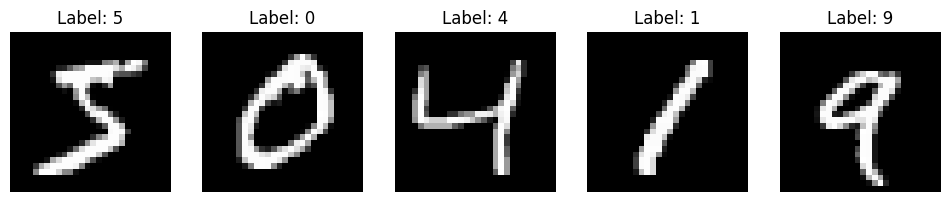

In [3]:
# 随机查看 5 张图片
plt.figure(figsize=(12, 4))
for index, (image, label) in enumerate(zip(X[:5], y[:5])):
    plt.subplot(1, 5, index + 1)
    # 将 784 维向量还原为 28x28 图像
    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f'Label: {label}')
    plt.axis('off')
plt.show()

## 4. 数据预处理

为了提高实验效率和模型效果，我们需要做两件事：
1. **归一化**: 将像素值从 0-255 缩放到 0-1 范围。
2. **采样与分割**: 由于 KNN 计算量大，我们在本实验中仅使用部分数据（例如 5000 条）进行演示，并按 8:2 分割训练集和测试集。

In [4]:
# 1. 归一化
X = X / 255.0

# 2. 为了演示速度，只取前 5000 个样本 (如果电脑性能好，可以尝试改为 10000 或更多)
sample_size = 5000
X_subset = X[:sample_size]
y_subset = y[:sample_size]

# 3. 分割训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

训练集大小: (4000, 784)
测试集大小: (1000, 784)


## 5. 模型训练 (KNN)

我们将使用 `KNeighborsClassifier`。KNN 是一种“懒惰学习”算法，它在训练阶段几乎不计算，主要时间花在预测阶段。

- **超参数 K**: 决定了我们参考最近的几个邻居。这里默认设为 3。

In [5]:
# 初始化模型
k = 3
knn_clf = KNeighborsClassifier(n_neighbors=k)

# 训练模型
print(f"开始训练 KNN 模型 (K={k})...")
start_time = time.time()
knn_clf.fit(X_train, y_train)
end_time = time.time()

print(f"模型训练完成！耗时: {end_time - start_time:.4f} 秒")

开始训练 KNN 模型 (K=3)...
模型训练完成！耗时: 0.0102 秒


## 6. 模型预测与评估

现在我们用从未见过的测试集来检验模型的准确性。

In [6]:
print("正在对测试集进行预测...")
start_time = time.time()
y_pred = knn_clf.predict(X_test)
end_time = time.time()

print(f"预测完成！耗时: {end_time - start_time:.4f} 秒")

正在对测试集进行预测...
预测完成！耗时: 2.0688 秒


In [7]:
# 计算并打印指标
acc = accuracy_score(y_test, y_pred)
print(f"\n=== 测试集准确率: {acc * 100:.2f}% ===\n")

print("详细分类报告:")
print(classification_report(y_test, y_pred))


=== 测试集准确率: 94.20% ===

详细分类报告:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       101
           1       0.89      0.99      0.94       120
           2       0.94      0.93      0.94        90
           3       0.91      0.94      0.93       102
           4       0.95      0.91      0.93       103
           5       0.95      0.89      0.92        84
           6       0.95      0.97      0.96       106
           7       0.98      0.94      0.96       120
           8       0.97      0.86      0.91        85
           9       0.91      0.96      0.93        89

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



### 6.1 混淆矩阵可视化
通过混淆矩阵，我们可以看到哪些数字最容易被混淆（例如 5 和 3，或者 9 和 4）。

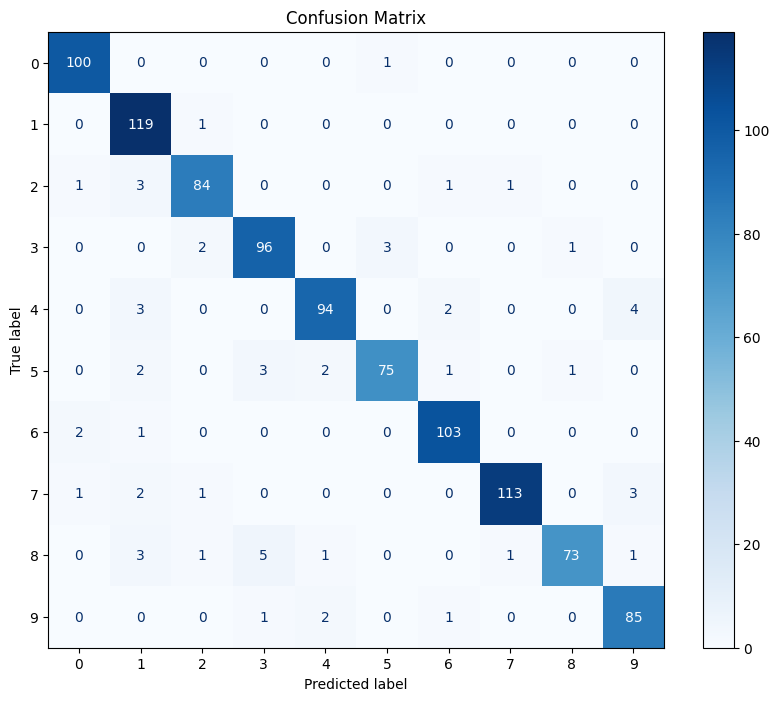

In [8]:
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix')
plt.show()

## 7. 错误案例分析
看看模型在哪些图片上犯了错，这对理解算法的局限性很有帮助。

共有 58 个样本被错误分类。


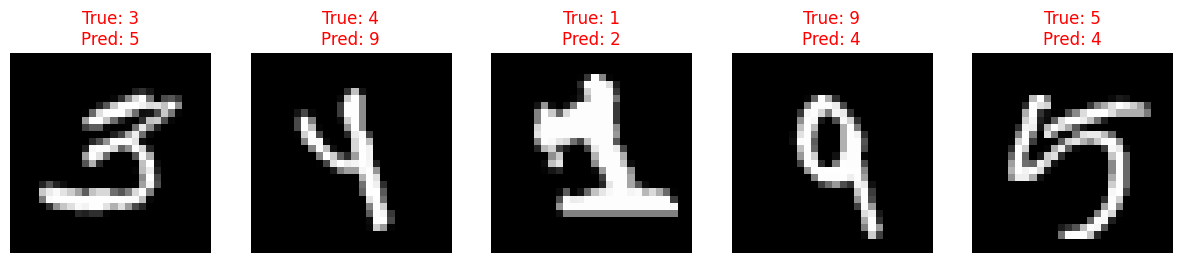

In [9]:
# 找出预测错误的索引
misclassified_indices = np.where(y_test != y_pred)[0]
print(f"共有 {len(misclassified_indices)} 个样本被错误分类。")

# 展示前 5 个错误
plt.figure(figsize=(15, 4))
for i, index in enumerate(misclassified_indices[:5]):
    plt.subplot(1, 5, i + 1)
    image = X_test[index].reshape(28, 28)
    # 标题显示: 真实标签 vs 预测标签
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {y_test[index]}\nPred: {y_pred[index]}", color='red')
    plt.axis('off')
plt.show()

# 随机抽查一张（看看模型猜对了没）
这段代码每次运行，都会随机换一张图片，你可以按 Ctrl + Enter 反复运行这个单元格来“抽查”模型。

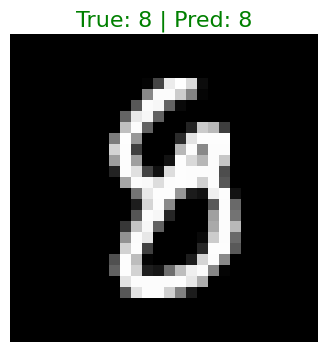

机器学习模型认为这张图是数字：8


In [46]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 随机选择一个测试样本的索引
random_idx = np.random.randint(0, len(X_test))

# 2. 获取该样本的数据和真实标签
target_image_flat = X_test[random_idx] # 获取 784维 向量
true_label = y_test[random_idx]        # 获取 真实标签

# 3. 让模型进行预测 (注意：predict 需要二维数组，所以要加 [])
# reshape(1, -1) 也可以，目的是变成 (1, 784)
prediction = knn_clf.predict([target_image_flat])
pred_label = prediction[0]

# 4. 可视化展示
plt.figure(figsize=(4, 4))
# 把 784维 向量 变回 28x28 的矩阵图像
plt.imshow(target_image_flat.reshape(28, 28), cmap='gray')

# 设置标题：如果对了显示绿色，错了显示红色
title_color = 'green' if pred_label == true_label else 'red'
plt.title(f"True: {true_label} | Pred: {pred_label}", color=title_color, fontsize=16)
plt.axis('off')
plt.show()

print(f"机器学习模型认为这张图是数字：{pred_label}")

透视 KNN 的“大脑” (不仅看结果，还看证据)，也可以按 Ctrl + Enter 反复运行这个单元格来“抽查”模型。

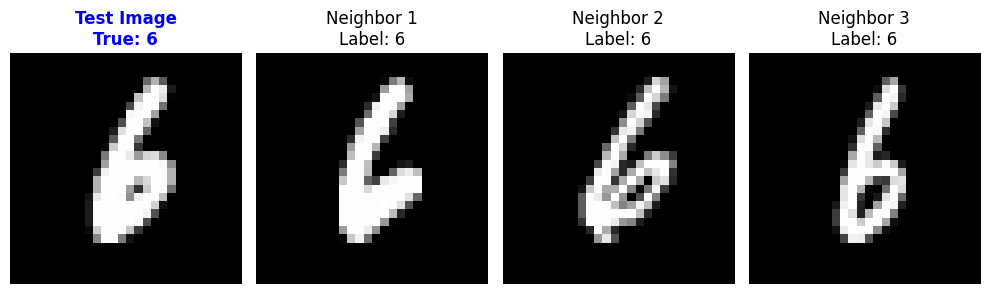

解释：
模型为什么觉得它是 6 ？
因为在训练数据集中，这 3 张图跟它长得最像！


In [49]:
# 1. 还是随机选一张测试图
random_idx = np.random.randint(0, len(X_test))
test_image = X_test[random_idx]
true_label = y_test[random_idx]

# 2. 让模型找出“最近的” k 个邻居
# kneighbors 返回两个数组：距离 和 索引
distances, indices = knn_clf.kneighbors([test_image])

# 3. 绘图：左边是测试图，右边是找到的邻居
plt.figure(figsize=(10, 3))

# === 画左边的测试图 ===
plt.subplot(1, 4, 1)
plt.imshow(test_image.reshape(28, 28), cmap='gray')
plt.title(f"Test Image\nTrue: {true_label}", color='blue', fontweight='bold')
plt.axis('off')

# === 画右边的 3 个邻居 (K=3) ===
for i, neighbor_idx in enumerate(indices[0]):
    plt.subplot(1, 4, i + 2)
    
    # 从训练集(X_train)里把这几个“邻居”找出来
    neighbor_image = X_train[neighbor_idx]
    neighbor_label = y_train[neighbor_idx]
    
    plt.imshow(neighbor_image.reshape(28, 28), cmap='gray')
    plt.title(f"Neighbor {i+1}\nLabel: {neighbor_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("解释：")
print(f"模型为什么觉得它是 {knn_clf.predict([test_image])[0]} ？")
print("因为在训练数据集中，这 3 张图跟它长得最像！")

## 8. 思考与拓展 (作业)

1. **改变 K 值**: 将 `n_neighbors` 改为 1, 5, 10，观察准确率如何变化？
2. **距离度量**: 查阅文档，尝试将距离度量方式从默认的欧氏距离 (`minkowski`, p=2) 改为曼哈顿距离 (`p=1`)，效果有变化吗？